# 01 Data Audit and Manifest Preparation

This notebook audits the downloaded public datasets and identifies whether each dataset contains images, masks, annotations, metadata, or only classification-style folders.

The goal is to determine which datasets are actually usable for optic disc/cup segmentation.

In [27]:
from pathlib import Path
import sys
import os
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

In [15]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

os.chdir(PROJECT_ROOT)

src_path = PROJECT_ROOT / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

PROJECT_ROOT

PosixPath('/sfs/gpfs/tardis/home/gsr3qz/Documents/MSDS/CAPSTONE/GitHub/Automated-Glaucoma-Screening-Using-AI-Enhanced-Ophthalmoscopy')

In [16]:
DATASET_KEYS = [
    "glaucoma_fundus_imaging_bundle",
    "papila",
]

DATASET_KEYS

['glaucoma_fundus_imaging_bundle', 'papila']

In [17]:
from glaucoma_segmentation.data.discover_files import inventory_registry_datasets

inventory_df, summary_df, candidate_df = inventory_registry_datasets(
    dataset_keys=DATASET_KEYS,
    save_reports=True,
)

summary_df

,dataset_key,extension,file_class,file_count,total_size_bytes
2,glaucoma_fundus_imaging_bundle,.jpg,image,10051,5013137525
6,glaucoma_fundus_imaging_bundle,.png,possible_mask_image,8631,39319157
0,glaucoma_fundus_imaging_bundle,.bmp,possible_mask_image,1200,3886650400
3,glaucoma_fundus_imaging_bundle,.json,possible_annotation,1023,1977090
4,glaucoma_fundus_imaging_bundle,.mat,possible_annotation,650,16796084
1,glaucoma_fundus_imaging_bundle,.csv,possible_annotation,3,115247
8,glaucoma_fundus_imaging_bundle,.tif,possible_mask_image,2,50146
5,glaucoma_fundus_imaging_bundle,.pkl,other,1,814
7,glaucoma_fundus_imaging_bundle,.pth,other,1,1107541735
15,papila,.txt,possible_annotation,1963,1091265


In [18]:
candidate_df[
    [
        "dataset_key",
        "relative_path",
        "extension",
        "file_class",
        "has_mask_keyword",
        "file_size_bytes",
    ]
].head(100)

,dataset_key,relative_path,extension,file_class,has_mask_keyword,file_size_bytes
0,glaucoma_fundus_imaging_bundle,G1020/G1020.csv,.csv,possible_annotation,False,18036
2,glaucoma_fundus_imaging_bundle,G1020/Images/image_0.json,.json,possible_annotation,False,1083
4,glaucoma_fundus_imaging_bundle,G1020/Images/image_1.json,.json,possible_annotation,False,1157
6,glaucoma_fundus_imaging_bundle,G1020/Images/image_10.json,.json,possible_annotation,False,848
8,glaucoma_fundus_imaging_bundle,G1020/Images/image_1000.json,.json,possible_annotation,False,903
...,...,...,...,...,...,...
190,glaucoma_fundus_imaging_bundle,G1020/Images/image_1260.json,.json,possible_annotation,False,895
192,glaucoma_fundus_imaging_bundle,G1020/Images/image_1261.json,.json,possible_annotation,False,1416
194,glaucoma_fundus_imaging_bundle,G1020/Images/image_1270.json,.json,possible_annotation,False,1731
196,glaucoma_fundus_imaging_bundle,G1020/Images/image_1271.json,.json,possible_annotation,False,1062


In [19]:
summary_df.sort_values(
    ["dataset_key", "file_count"],
    ascending=[True, False],
)

,dataset_key,extension,file_class,file_count,total_size_bytes
2,glaucoma_fundus_imaging_bundle,.jpg,image,10051,5013137525
6,glaucoma_fundus_imaging_bundle,.png,possible_mask_image,8631,39319157
0,glaucoma_fundus_imaging_bundle,.bmp,possible_mask_image,1200,3886650400
3,glaucoma_fundus_imaging_bundle,.json,possible_annotation,1023,1977090
4,glaucoma_fundus_imaging_bundle,.mat,possible_annotation,650,16796084
1,glaucoma_fundus_imaging_bundle,.csv,possible_annotation,3,115247
8,glaucoma_fundus_imaging_bundle,.tif,possible_mask_image,2,50146
5,glaucoma_fundus_imaging_bundle,.pkl,other,1,814
7,glaucoma_fundus_imaging_bundle,.pth,other,1,1107541735
15,papila,.txt,possible_annotation,1963,1091265


In [20]:
dataset_summary = (
    inventory_df
    .groupby(["dataset_key", "file_class"])
    .size()
    .reset_index(name="file_count")
    .pivot(index="dataset_key", columns="file_class", values="file_count")
    .fillna(0)
    .astype(int)
)

dataset_summary

file_class,image,other,possible_annotation,possible_mask_image
dataset_key,,,,
glaucoma_fundus_imaging_bundle,10051,2,1676,9833
papila,488,4,1985,488


## Initial audit complete

The next step is to review the candidate masks/annotations and determine which datasets can support optic disc/cup segmentation.

After that, the manifest-building portion of this notebook will create structured image/mask pair records.

## Path-pattern inspection

Inspect folder patterns inside the audited datasets so we can identify likely fundus image folders, mask folders, and annotation folders before writing manifest-building code.

In [21]:
# Find project root from wherever the notebook is opened
def find_project_root(start_path: Path | None = None) -> Path:
    start_path = start_path or Path.cwd()
    for path in [start_path, *start_path.parents]:
        if (path / "configs").exists() and (path / "src").exists():
            return path
    raise FileNotFoundError("Could not find project root containing configs/ and src/")

PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from glaucoma_segmentation.data.discover_files import inventory_registry_datasets

DATASET_KEYS = ["glaucoma_fundus_imaging_bundle", "papila"]

inventory_df, summary_df, candidate_df = inventory_registry_datasets(
    dataset_keys=DATASET_KEYS,
    save_reports=True,
)

summary_df

,dataset_key,extension,file_class,file_count,total_size_bytes
2,glaucoma_fundus_imaging_bundle,.jpg,image,10051,5013137525
6,glaucoma_fundus_imaging_bundle,.png,possible_mask_image,8631,39319157
0,glaucoma_fundus_imaging_bundle,.bmp,possible_mask_image,1200,3886650400
3,glaucoma_fundus_imaging_bundle,.json,possible_annotation,1023,1977090
4,glaucoma_fundus_imaging_bundle,.mat,possible_annotation,650,16796084
1,glaucoma_fundus_imaging_bundle,.csv,possible_annotation,3,115247
8,glaucoma_fundus_imaging_bundle,.tif,possible_mask_image,2,50146
5,glaucoma_fundus_imaging_bundle,.pkl,other,1,814
7,glaucoma_fundus_imaging_bundle,.pth,other,1,1107541735
15,papila,.txt,possible_annotation,1963,1091265


In [22]:
path_parts = candidate_df["relative_path"].astype(str).str.split("/", expand=True)

path_patterns = (
    candidate_df
    .assign(
        top_folder=path_parts[0],
        second_folder=path_parts[1].fillna(""),
        third_folder=path_parts[2].fillna("")
    )
    .groupby(["dataset_key", "top_folder", "second_folder", "file_class"])
    .size()
    .reset_index(name="n_files")
    .sort_values(["dataset_key", "n_files"], ascending=[True, False])
)

output_path = PROJECT_ROOT / "reports" / "data_audit" / "public_dataset_path_patterns.csv"
path_patterns.to_csv(output_path, index=False)

print(f"Saved path-pattern summary to: {output_path}")
path_patterns.head(75)

Saved path-pattern summary to: /sfs/gpfs/tardis/home/gsr3qz/Documents/MSDS/CAPSTONE/GitHub/Automated-Glaucoma-Screening-Using-AI-Enhanced-Ophthalmoscopy/reports/data_audit/public_dataset_path_patterns.csv


,dataset_key,top_folder,second_folder,file_class,n_files
12,glaucoma_fundus_imaging_bundle,REFUGE,Masks_Square,possible_mask_image,1200
14,glaucoma_fundus_imaging_bundle,REFUGE,test,possible_mask_image,1200
16,glaucoma_fundus_imaging_bundle,REFUGE,train,possible_mask_image,1200
18,glaucoma_fundus_imaging_bundle,REFUGE,val,possible_mask_image,1200
3,glaucoma_fundus_imaging_bundle,G1020,Masks_Cropped,possible_mask_image,1040
1,glaucoma_fundus_imaging_bundle,G1020,Images,possible_annotation,1020
2,glaucoma_fundus_imaging_bundle,G1020,Masks,possible_mask_image,1020
4,glaucoma_fundus_imaging_bundle,G1020,Masks_Square,possible_mask_image,1020
7,glaucoma_fundus_imaging_bundle,ORIGA,Masks_Square,possible_mask_image,651
5,glaucoma_fundus_imaging_bundle,ORIGA,Masks,possible_mask_image,650


In [23]:
image_like_patterns = (
    path_patterns[
        path_patterns["file_class"].isin(
            ["image", "possible_mask_image", "possible_annotation"]
        )
    ]
    .sort_values(
        ["dataset_key", "top_folder", "second_folder", "file_class"]
    )
)

output_path = PROJECT_ROOT / "reports" / "data_audit" / "public_dataset_image_like_path_patterns.csv"
image_like_patterns.to_csv(output_path, index=False)

print(f"Saved image-like path-pattern summary to: {output_path}")
image_like_patterns

Saved image-like path-pattern summary to: /sfs/gpfs/tardis/home/gsr3qz/Documents/MSDS/CAPSTONE/GitHub/Automated-Glaucoma-Screening-Using-AI-Enhanced-Ophthalmoscopy/reports/data_audit/public_dataset_image_like_path_patterns.csv


,dataset_key,top_folder,second_folder,file_class,n_files
0,glaucoma_fundus_imaging_bundle,G1020,G1020.csv,possible_annotation,1
1,glaucoma_fundus_imaging_bundle,G1020,Images,possible_annotation,1020
2,glaucoma_fundus_imaging_bundle,G1020,Masks,possible_mask_image,1020
3,glaucoma_fundus_imaging_bundle,G1020,Masks_Cropped,possible_mask_image,1040
4,glaucoma_fundus_imaging_bundle,G1020,Masks_Square,possible_mask_image,1020
5,glaucoma_fundus_imaging_bundle,ORIGA,Masks,possible_mask_image,650
6,glaucoma_fundus_imaging_bundle,ORIGA,Masks_Cropped,possible_mask_image,650
7,glaucoma_fundus_imaging_bundle,ORIGA,Masks_Square,possible_mask_image,651
8,glaucoma_fundus_imaging_bundle,ORIGA,OrigaList.csv,possible_annotation,1
9,glaucoma_fundus_imaging_bundle,ORIGA,Semi-automatic-annotations,possible_annotation,650


## ORIGA image-mask pairing inspection

Inspect the ORIGA folders inside the glaucoma fundus imaging bundle to confirm whether image files and mask files have matching IDs before writing manifest-building code.

In [24]:
inventory_path = PROJECT_ROOT / "reports" / "data_audit" / "public_dataset_file_inventory.csv"

inventory_df = pd.read_csv(inventory_path)

origa_df = inventory_df[
    (inventory_df["dataset_key"] == "glaucoma_fundus_imaging_bundle")
    & (inventory_df["relative_path"].astype(str).str.startswith("ORIGA/"))
].copy()

origa_df["folder"] = origa_df["relative_path"].astype(str).apply(
    lambda x: "/".join(x.split("/")[:2])
)

origa_df["file_id"] = origa_df["file_name"].astype(str).str.replace(
    r"\.[^.]+$", "", regex=True
)

origa_folder_summary = (
    origa_df
    .groupby(["folder", "extension", "file_class"])
    .size()
    .reset_index(name="n_files")
    .sort_values(["folder", "extension", "file_class"])
)

origa_folder_summary

,folder,extension,file_class,n_files
0,ORIGA/Images,.jpg,image,650
1,ORIGA/Images_Cropped,.jpg,image,650
2,ORIGA/Images_Square,.jpg,image,651
3,ORIGA/Masks,.png,possible_mask_image,650
4,ORIGA/Masks_Cropped,.png,possible_mask_image,650
5,ORIGA/Masks_Square,.png,possible_mask_image,651
6,ORIGA/OrigaList.csv,.csv,possible_annotation,1
7,ORIGA/Semi-automatic-annotations,.mat,possible_annotation,650
8,ORIGA/Semi-automatic-annotations,.tif,possible_mask_image,2
9,ORIGA/origa_info.csv,.csv,possible_annotation,1


In [25]:
origa_pairs_to_check = [
    ("ORIGA/Images", "ORIGA/Masks"),
    ("ORIGA/Images_Cropped", "ORIGA/Masks_Cropped"),
    ("ORIGA/Images_Square", "ORIGA/Masks_Square"),
]

pairing_rows = []

for image_folder, mask_folder in origa_pairs_to_check:
    image_ids = set(
        origa_df.loc[origa_df["folder"] == image_folder, "file_id"]
        .astype(str)
        .tolist()
    )
    mask_ids = set(
        origa_df.loc[origa_df["folder"] == mask_folder, "file_id"]
        .astype(str)
        .tolist()
    )

    matched_ids = image_ids & mask_ids
    image_only_ids = image_ids - mask_ids
    mask_only_ids = mask_ids - image_ids

    pairing_rows.append(
        {
            "image_folder": image_folder,
            "mask_folder": mask_folder,
            "n_images": len(image_ids),
            "n_masks": len(mask_ids),
            "n_exact_id_matches": len(matched_ids),
            "n_image_without_mask": len(image_only_ids),
            "n_mask_without_image": len(mask_only_ids),
            "sample_image_only_ids": sorted(list(image_only_ids))[:5],
            "sample_mask_only_ids": sorted(list(mask_only_ids))[:5],
        }
    )

origa_pairing_summary = pd.DataFrame(pairing_rows)

output_path = PROJECT_ROOT / "reports" / "data_audit" / "origa_image_mask_pairing_summary.csv"
origa_pairing_summary.to_csv(output_path, index=False)

print(f"Saved ORIGA image-mask pairing summary to: {output_path}")
origa_pairing_summary

Saved ORIGA image-mask pairing summary to: /sfs/gpfs/tardis/home/gsr3qz/Documents/MSDS/CAPSTONE/GitHub/Automated-Glaucoma-Screening-Using-AI-Enhanced-Ophthalmoscopy/reports/data_audit/origa_image_mask_pairing_summary.csv


,image_folder,mask_folder,n_images,n_masks,n_exact_id_matches,n_image_without_mask,n_mask_without_image,sample_image_only_ids,sample_mask_only_ids
0,ORIGA/Images,ORIGA/Masks,650,650,650,0,0,[],[]
1,ORIGA/Images_Cropped,ORIGA/Masks_Cropped,650,650,650,0,0,[],[]
2,ORIGA/Images_Square,ORIGA/Masks_Square,651,651,650,1,1,[._003],[._005]


In [26]:
origa_image_df = origa_df[
    origa_df["folder"] == "ORIGA/Images"
].copy()

origa_mask_df = origa_df[
    origa_df["folder"] == "ORIGA/Masks"
].copy()

origa_image_df = origa_image_df.rename(
    columns={
        "relative_path": "image_relative_path",
        "file_name": "image_file_name",
    }
)

origa_mask_df = origa_mask_df.rename(
    columns={
        "relative_path": "mask_relative_path",
        "file_name": "mask_file_name",
    }
)

origa_candidate_pairs = (
    origa_image_df[["file_id", "image_relative_path", "image_file_name"]]
    .merge(
        origa_mask_df[["file_id", "mask_relative_path", "mask_file_name"]],
        on="file_id",
        how="inner",
    )
    .sort_values("file_id")
    .reset_index(drop=True)
)

output_path = PROJECT_ROOT / "reports" / "data_audit" / "origa_candidate_image_mask_pairs.csv"
origa_candidate_pairs.to_csv(output_path, index=False)

print(f"Saved ORIGA candidate image-mask pairs to: {output_path}")
print(f"Number of paired ORIGA image-mask records: {len(origa_candidate_pairs)}")

origa_candidate_pairs.head(10)

Saved ORIGA candidate image-mask pairs to: /sfs/gpfs/tardis/home/gsr3qz/Documents/MSDS/CAPSTONE/GitHub/Automated-Glaucoma-Screening-Using-AI-Enhanced-Ophthalmoscopy/reports/data_audit/origa_candidate_image_mask_pairs.csv
Number of paired ORIGA image-mask records: 650


,file_id,image_relative_path,image_file_name,mask_relative_path,mask_file_name
0,001,ORIGA/Images/001.jpg,001.jpg,ORIGA/Masks/001.png,001.png
1,002,ORIGA/Images/002.jpg,002.jpg,ORIGA/Masks/002.png,002.png
2,003,ORIGA/Images/003.jpg,003.jpg,ORIGA/Masks/003.png,003.png
3,004,ORIGA/Images/004.jpg,004.jpg,ORIGA/Masks/004.png,004.png
4,005,ORIGA/Images/005.jpg,005.jpg,ORIGA/Masks/005.png,005.png
5,006,ORIGA/Images/006.jpg,006.jpg,ORIGA/Masks/006.png,006.png
6,007,ORIGA/Images/007.jpg,007.jpg,ORIGA/Masks/007.png,007.png
7,008,ORIGA/Images/008.jpg,008.jpg,ORIGA/Masks/008.png,008.png
8,009,ORIGA/Images/009.jpg,009.jpg,ORIGA/Masks/009.png,009.png
9,010,ORIGA/Images/010.jpg,010.jpg,ORIGA/Masks/010.png,010.png


## ORIGA visual QA

Display a small sample of ORIGA image-mask pairs to confirm that the masks visually align with the fundus images before creating a formal manifest.

file_id: 638
image: ORIGA/Images/638.jpg
mask:  ORIGA/Masks/638.png
image size: (2461, 2048)
mask size:  (2461, 2048)
mask unique values sample: [0 1 2]
--------------------------------------------------------------------------------


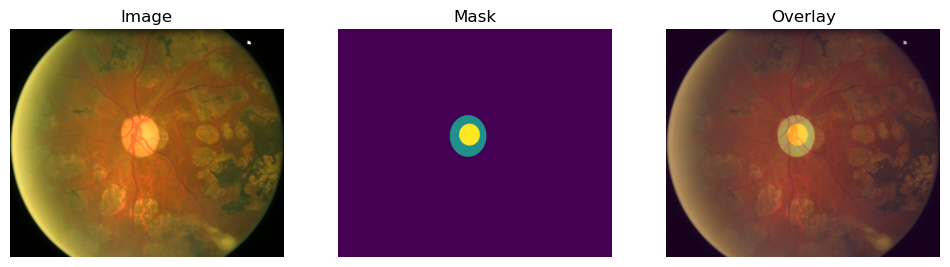

file_id: 221
image: ORIGA/Images/221.jpg
mask:  ORIGA/Masks/221.png
image size: (2591, 2048)
mask size:  (2591, 2048)
mask unique values sample: [0 1 2]
--------------------------------------------------------------------------------


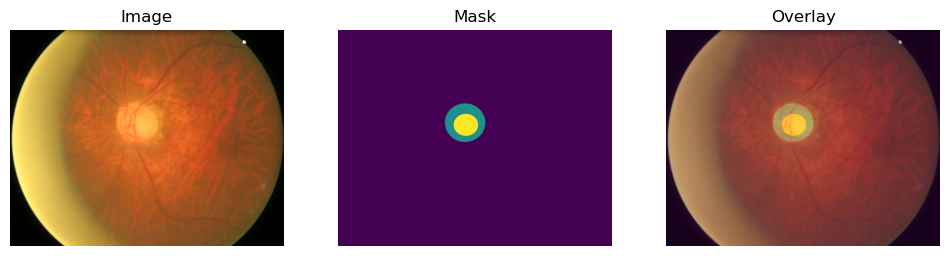

file_id: 429
image: ORIGA/Images/429.jpg
mask:  ORIGA/Masks/429.png
image size: (2493, 2048)
mask size:  (2493, 2048)
mask unique values sample: [0 1 2]
--------------------------------------------------------------------------------


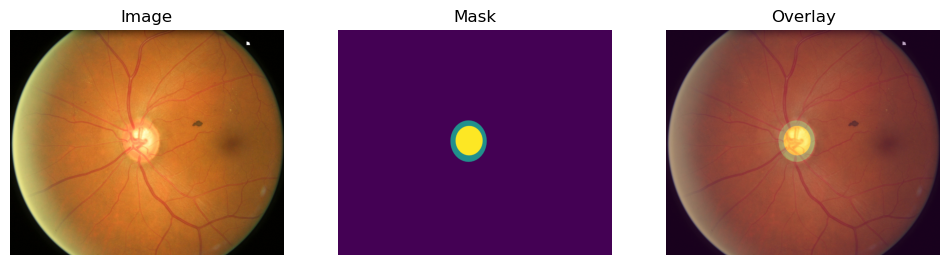

file_id: 327
image: ORIGA/Images/327.jpg
mask:  ORIGA/Masks/327.png
image size: (2300, 2048)
mask size:  (2300, 2048)
mask unique values sample: [0 1 2]
--------------------------------------------------------------------------------


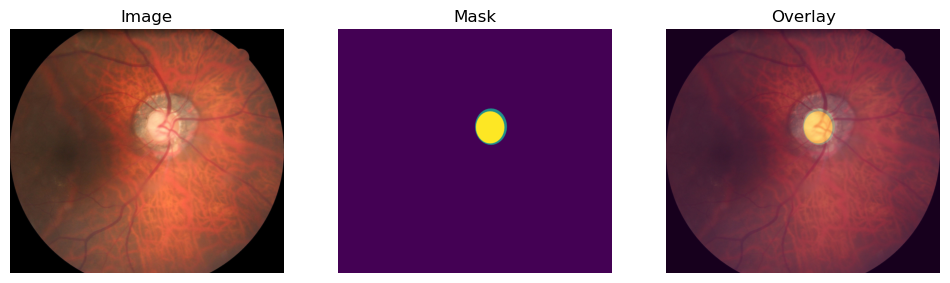

file_id: 73
image: ORIGA/Images/073.jpg
mask:  ORIGA/Masks/073.png
image size: (2468, 2048)
mask size:  (2468, 2048)
mask unique values sample: [0 1 2]
--------------------------------------------------------------------------------


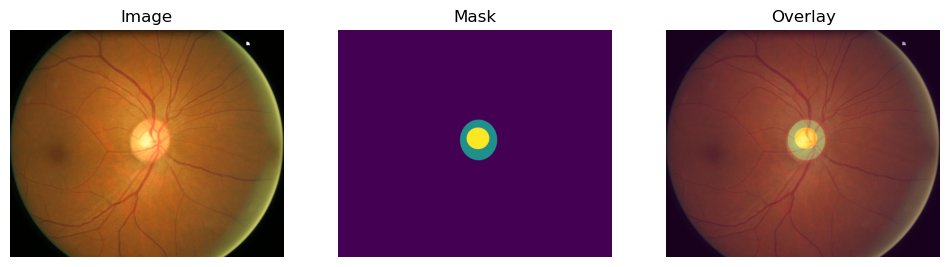

In [28]:
pairs_path = PROJECT_ROOT / "reports" / "data_audit" / "origa_candidate_image_mask_pairs.csv"
origa_pairs_df = pd.read_csv(pairs_path)

dataset_root = PROJECT_ROOT / "data" / "external" / "kaggle" / "glaucoma_fundus_imaging_bundle"

sample_pairs = origa_pairs_df.sample(n=5, random_state=42).reset_index(drop=True)

for _, row in sample_pairs.iterrows():
    image_path = dataset_root / row["image_relative_path"]
    mask_path = dataset_root / row["mask_relative_path"]

    image = Image.open(image_path).convert("RGB")
    mask = Image.open(mask_path).convert("L")

    image_array = np.array(image)
    mask_array = np.array(mask)

    print(f"file_id: {row['file_id']}")
    print(f"image: {row['image_relative_path']}")
    print(f"mask:  {row['mask_relative_path']}")
    print(f"image size: {image.size}")
    print(f"mask size:  {mask.size}")
    print(f"mask unique values sample: {np.unique(mask_array)[:20]}")
    print("-" * 80)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(image_array)
    plt.title("Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(mask_array)
    plt.title("Mask")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(image_array)
    plt.imshow(mask_array, alpha=0.35)
    plt.title("Overlay")
    plt.axis("off")

    plt.show()

In [29]:
visual_qa_rows = []

for _, row in sample_pairs.iterrows():
    image_path = dataset_root / row["image_relative_path"]
    mask_path = dataset_root / row["mask_relative_path"]

    image = Image.open(image_path).convert("RGB")
    mask = Image.open(mask_path).convert("L")

    mask_array = np.array(mask)
    unique_values = sorted(np.unique(mask_array).tolist())

    visual_qa_rows.append(
        {
            "file_id": row["file_id"],
            "image_relative_path": row["image_relative_path"],
            "mask_relative_path": row["mask_relative_path"],
            "image_width": image.size[0],
            "image_height": image.size[1],
            "mask_width": mask.size[0],
            "mask_height": mask.size[1],
            "sizes_match": image.size == mask.size,
            "mask_unique_values": unique_values,
            "visual_alignment_reviewed": True,
            "notes": "Sample reviewed in notebook; mask appears aligned over optic disc/cup region.",
        }
    )

origa_visual_qa_summary = pd.DataFrame(visual_qa_rows)

output_path = PROJECT_ROOT / "reports" / "data_audit" / "origa_visual_qa_summary.csv"
origa_visual_qa_summary.to_csv(output_path, index=False)

print(f"Saved ORIGA visual QA summary to: {output_path}")
origa_visual_qa_summary

Saved ORIGA visual QA summary to: /sfs/gpfs/tardis/home/gsr3qz/Documents/MSDS/CAPSTONE/GitHub/Automated-Glaucoma-Screening-Using-AI-Enhanced-Ophthalmoscopy/reports/data_audit/origa_visual_qa_summary.csv


,file_id,image_relative_path,mask_relative_path,image_width,image_height,mask_width,mask_height,sizes_match,mask_unique_values,visual_alignment_reviewed,notes
0,638,ORIGA/Images/638.jpg,ORIGA/Masks/638.png,2461,2048,2461,2048,True,"[0, 1, 2]",True,Sample reviewed in notebook; mask appears alig...
1,221,ORIGA/Images/221.jpg,ORIGA/Masks/221.png,2591,2048,2591,2048,True,"[0, 1, 2]",True,Sample reviewed in notebook; mask appears alig...
2,429,ORIGA/Images/429.jpg,ORIGA/Masks/429.png,2493,2048,2493,2048,True,"[0, 1, 2]",True,Sample reviewed in notebook; mask appears alig...
3,327,ORIGA/Images/327.jpg,ORIGA/Masks/327.png,2300,2048,2300,2048,True,"[0, 1, 2]",True,Sample reviewed in notebook; mask appears alig...
4,73,ORIGA/Images/073.jpg,ORIGA/Masks/073.png,2468,2048,2468,2048,True,"[0, 1, 2]",True,Sample reviewed in notebook; mask appears alig...
